## PAW wavelet clustering

In [1]:
""" 
IMPORTS
"""
import os
import numpy as np
import pandas as pd
from one.api import ONE
from matplotlib import pyplot as plt
from scipy import stats
from kneed import KneeLocator
from scipy.spatial.distance import cdist
from sklearn.cluster import KMeans
import seaborn as sns
from sklearn.manifold import TSNE
from matplotlib.colors import ListedColormap
from sklearn.decomposition import PCA

# Get my functions
from segmentation_functions import idxs_from_files

one = ONE(mode='remote')

In [2]:
""" 
LOAD DATA AND PARAMETERS
"""
# LOAD DATA
base_path = '/Users/ineslaranjeira/Google Drive/O meu disco/CCU/PhD Project/paper-individuality/data/newly_generated/segmentation/'
base_path = '/home/ines/repositories/representation_learning_variability/paper-individuality/data/'
# base_path = '/home/ines/repositories/representation_learning_variability/' + 'paper-individuality/segmentation/1_camera_setup/temp_data/'
# base_path = "/Users/ineslaranjeira/Google Drive/O meu disco/CCU/PhD Project/paper-individuality/data/training/session_1/"

data_path = base_path + 'design_matrices/'

data_path = '/home/ines/repositories/representation_learning_variability/paper-individuality/data/design_matrices/1_camera_setup/last_training/'
base_path = '/home/ines/repositories/representation_learning_variability/paper-individuality/data/training/'


all_files = os.listdir(data_path)
design_matrices = [item for item in all_files if 'design_matrix' in item and 'standardized' not in item]

exclude_neuromodulator_eids = ['3dffc578-3fa8-4d01-b0df-a61a5593be46',
    '41cc34ab-deda-480b-b957-380abb2117c0',
    '65f90bf6-5124-430a-ab73-134ac6fb374f',
    'f24c2389-1716-4827-a14c-3a11dee6a754',
    '173b48e4-8201-44f5-8c36-7886afcd82e2',
    '820790a2-7ae5-4daa-8871-e8e55d0a317d',
    '699dc94d-e141-42d7-afa5-ab9a1fa000f8',
    '296c7e55-e338-43f2-b5bb-2ad6e0c52436',
    '8af59882-3b50-4f1b-873c-46040587775b',
    '4ac35324-a13c-4517-a61f-7183a2f6ff44',
    '2d2e9a22-683a-409c-91e8-79196e10be93',
    '4f7ee34f-71d7-4054-88e6-ff1179762461',
    'aa211f0c-94df-4f8a-9775-b8fcec3f5138',
    '1c9d6859-0acd-4e41-9def-a9a08384c18f',
    'f930de5b-41d4-4bd7-9a54-8ae4f81b99f7',
    '5782c52f-81dc-403f-bb94-4f39dc4a92a3']

exclude_training_eids = [
    "b117ed10-6871-42b3-9193-ca708dac4353",
    "4636ab1e-0522-472b-8eda-69b4223677c7",
    "167f98be-6704-430f-b531-2d4ab2aae932",
    "75e5c60b-462c-4a00-ae04-77baf489bdef",
    "ed9fca43-8b3e-414d-baf3-caeed8edd0ac",
    "70ec358f-a55b-4b28-9a7a-0a674012930f",
    "f1ee85e7-f863-4648-b32f-9c7b90cc3fdf",
    "a53fed99-d34c-4bf5-a7ec-c0ff7e6350f3",
    "6a6670e3-56a5-4d37-8e07-14262f954f3f",
    "cda5ec4d-f5a3-4cbc-8547-40b57c840d92",
    "158e13ee-8eb6-4473-aa3c-1f940b004570",
]

sessions_to_exclude = ['a8a8af78-16de-4841-ab07-fde4b5281a03',
    '8c33abef-3d3e-4d42-9f27-445e9def08f9',
    'ebe2efe3-e8a1-451a-8947-76ef42427cc9',
    # '0deb75fb-9088-42d9-b744-012fb8fc4afb',  # bad fit (should not be excluded here)
    # 'a71175be-d1fd-47a3-aa93-b830ea3634a1',  # bad fit (should not be excluded here)
    '91bac580-76ed-41ab-ac07-89051f8d7f6e',
    '8a1cf4ef-06e3-4c72-9bc7-e1baa189841b',
    # '02fbb6da-3034-47d6-a61b-7d06c796a830',  # bad fit (should not be excluded here)
    '64977c74-9c04-437a-9ea1-50386c4996db',
    '90e524a2-aa63-47ce-b5b8-1b1941a1223a',
    '30af8629-7b96-45b7-8778-374720ddbc5e',
    # '510b1a50-825d-44ce-86f6-9678f5396e02',  # bad fit (should not be excluded here)
    'f3eeb2d4-87ce-49ae-8a74-21665f6f1536',
    # '49368f16-de69-4647-9a7a-761e94517821',  # bad fit (should not be excluded here)
    # '7f6b86f9-879a-4ea2-8531-294a221af5d0',  # bad fit (should not be excluded here)
    'fcd49e34-f07b-441c-b2ac-cb8c462ec5ac']  # Ago 7 2026



# exclude bad sessions to save time
filtered_design_matrices = np.array([s for s in design_matrices if s.split('_')[2] not in sessions_to_exclude])
print(f'{len(design_matrices)} -> {len(filtered_design_matrices)} (excluded {len(design_matrices) - len(filtered_design_matrices)})')

idxs, mouse_names = idxs_from_files(filtered_design_matrices)
idxs, mouse_names = idxs_from_files(design_matrices)

velocity = True
var = 'wheel'
var = 'paw_wheel'
var = 'paw'
cutoff = 0.95  # Variance explained cutoff for PCA
zscore = True  # Whether to z-score the data before PCA and clustering

if var == 'paw':
    # super_session = np.load(base_path+'supersession_wavelets_paw03-19-2026')  # This is with added data
    wavelet_path = base_path + 'paw_wavelets/'
    # super_session = np.load(base_path+'supersession_wavelets_paw06-12-2026')  # This is with added data
    # super_session = np.load(base_path+'session_zscored_supersession_wavelets_paw06-12-2026')  # This is with added data
    # super_session = np.load(base_path+'session_zscored_supersession_wavelets_paw15-07-2026')  # This is from NM dataset
    # super_session = np.load(base_path+'session_zscored_supersession_wavelets_paw16-07-2026')  # This is from NM dataset
    super_session = np.load(base_path+'session_zscored_supersession_wavelets_paw08-19-2026')  # This is from new_qc_bwm
    if zscore:
        states_path = base_path + 'paw_states_session_zscored/'
        states_path = base_path + 'paw_states_session_zscored_new_bwm/'
    else:
        states_path = base_path + 'paw_states/'
        
elif var == 'left_paw':
    wavelet_path = base_path + 'left_paw_wavelets/'
    super_session = np.load(base_path+'session_zscored_supersession_wavelets_left_paw17-07-2026')  
    if zscore:
        states_path = base_path + 'left_paw_states_session_zscored/'
        states_path = base_path + 'left_paw_states_session_zscored_new_bwm/'
    else:
        states_path = base_path + 'left_paw_states/'

elif var == 'wheel':
    super_session = np.load(base_path+'session_zscored_supersession_wavelets_wheel17-07-2026')
    wavelet_path = base_path + 'wheel_wavelets/'
    if zscore:
        states_path = base_path + 'wheel_states_session_zscored/'    
    else:
        states_path = base_path + 'wheel_states/'
        
elif var == 'paw_wheel':
    wavelet_path = base_path + 'paw_wavelets/'
    # super_session = np.load(base_path+'supersession_wavelets_paw06-12-2026')  # This is with added data
    super_session = np.load(base_path+'session_zscored_supersession_wavelets_paw06-12-2026')  # This is with added data
    # super_session = np.load(base_path+'session_zscored_supersession_wavelets_paw15-07-2026')  # This is from NM dataset
    # super_session = np.load(base_path+'session_zscored_supersession_wavelets_paw16-07-2026')  # This is from NM dataset
    if zscore:
        states_path = base_path + 'left_paw_wheel_states_session_zscored/'
    else:
        states_path = base_path + 'left_paw_wheel_states/'
    

55 -> 55 (excluded 0)


FileNotFoundError: [Errno 2] No such file or directory: '/home/ines/repositories/representation_learning_variability/paper-individuality/data/training/session_zscored_supersession_wavelets_paw08-19-2026'

In [3]:
paws = ['l_paw',  'r_paw']
paws = ['l_paw']

if var == 'paw':
    var_init = ['l_paw_x', 'l_paw_y', 'r_paw_x', 'r_paw_y', 
                    'l_paw_x0.5', 'l_paw_x1.0', 'l_paw_x2.0', 'l_paw_x4.0', 'l_paw_x8.0', 'l_paw_x16.0', 'l_paw_x32.0',
                    'l_paw_y0.5', 'l_paw_y1.0', 'l_paw_y2.0', 'l_paw_y4.0', 'l_paw_y8.0', 'l_paw_y16.0', 'l_paw_y32.0',
                    'r_paw_x0.5', 'r_paw_x1.0', 'r_paw_x2.0', 'r_paw_x4.0', 'r_paw_x8.0', 'r_paw_x16.0', 'r_paw_x32.0',
                    'r_paw_y0.5', 'r_paw_y1.0', 'r_paw_y2.0', 'r_paw_y4.0', 'r_paw_y8.0', 'r_paw_y16.0', 'r_paw_y32.0']
    var_interest = var_init[4:]
    var_interest = ['l_paw_x0.5', 'l_paw_x1.0', 'l_paw_x2.0', 'l_paw_x4.0', 'l_paw_x8.0', 
                    'l_paw_y0.5', 'l_paw_y1.0', 'l_paw_y2.0', 'l_paw_y4.0', 'l_paw_y8.0', 
                    'r_paw_x0.5', 'r_paw_x1.0', 'r_paw_x2.0', 'r_paw_x4.0', 'r_paw_x8.0', 
                    'r_paw_y0.5', 'r_paw_y1.0', 'r_paw_y2.0', 'r_paw_y4.0', 'r_paw_y8.0',]
    var_interest = ['l_paw_x0.5', 'l_paw_x1.0', 'l_paw_x2.0', 'l_paw_x4.0', 'l_paw_x8.0', 'l_paw_x16.0',
                    'l_paw_y0.5', 'l_paw_y1.0', 'l_paw_y2.0', 'l_paw_y4.0', 'l_paw_y8.0', 'l_paw_y16.0',
                    'r_paw_x0.5', 'r_paw_x1.0', 'r_paw_x2.0', 'r_paw_x4.0', 'r_paw_x8.0', 'r_paw_x16.0',
                    'r_paw_y0.5', 'r_paw_y1.0', 'r_paw_y2.0', 'r_paw_y4.0', 'r_paw_y8.0','r_paw_y16.0']
    var_interest = ['l_paw_x0.5','l_paw_x1.0', 'l_paw_x2.0', 'l_paw_x4.0', 'l_paw_x8.0', 
                    'r_paw_x0.5', 'r_paw_x1.0', 'r_paw_x2.0', 'r_paw_x4.0', 'r_paw_x8.0']
    # var_interest = ['l_paw_x0.5', 'l_paw_x1.0', 'l_paw_x2.0', 'l_paw_x4.0', 'l_paw_x8.0', 
    #                 'r_paw_x0.5', 'r_paw_x1.0', 'r_paw_x2.0', 'r_paw_x4.0', 'r_paw_x8.0']
    var_interest = ['l_paw_x0.5', 'l_paw_x1.0', 'l_paw_x2.0', 'l_paw_x4.0', 'l_paw_x8.0', 
                    'l_paw_y0.5', 'l_paw_y1.0', 'l_paw_y2.0', 'l_paw_y4.0', 'l_paw_y8.0', 
                    'r_paw_x0.5', 'r_paw_x1.0', 'r_paw_x2.0', 'r_paw_x4.0', 'r_paw_x8.0', 
                    'r_paw_y0.5', 'r_paw_y1.0', 'r_paw_y2.0', 'r_paw_y4.0', 'r_paw_y8.0',]
elif var == 'left_paw':
    var_init = ['l_paw_x', 'l_paw_y', 'r_paw_x', 'r_paw_y', 
                    'l_paw_x0.5', 'l_paw_x1.0', 'l_paw_x2.0', 'l_paw_x4.0', 'l_paw_x8.0', 'l_paw_x16.0', 'l_paw_x32.0',
                    'l_paw_y0.5', 'l_paw_y1.0', 'l_paw_y2.0', 'l_paw_y4.0', 'l_paw_y8.0', 'l_paw_y16.0', 'l_paw_y32.0']
    var_interest = ['l_paw_x0.5', 'l_paw_x1.0', 'l_paw_x2.0', 'l_paw_x4.0', 'l_paw_x8.0',
                    'l_paw_y0.5', 'l_paw_y1.0', 'l_paw_y2.0', 'l_paw_y4.0', 'l_paw_y8.0']
elif var == 'wheel':
    var_init = ['avg_wheel_vel0.5', 'avg_wheel_vel1.0', 'avg_wheel_vel2.0', 'avg_wheel_vel4.0', 'avg_wheel_vel8.0', 
                    'avg_wheel_vel16.0', 'avg_wheel_vel32.0',
                    ]
    # var_init = ['avg_wheel_vel0.5', 'avg_wheel_vel1.0', 'avg_wheel_vel2.0', 'avg_wheel_vel4.0', 'avg_wheel_vel8.0', 
    #                 'avg_wheel_vel16.0', 'avg_wheel_vel32.0',
    #                 ]
    var_interest = var_init[:-2]
    var_interest = var_init[3:]
elif var == 'paw_wheel':
    var_init = ['avg_wheel_vel',  'l_paw_x', 'l_paw_y', 'r_paw_x', 'r_paw_y', 
                    'l_paw_x0.5', 'l_paw_x1.0', 'l_paw_x2.0', 'l_paw_x4.0', 'l_paw_x8.0', 'l_paw_x16.0', 'l_paw_x32.0',
                    'l_paw_y0.5', 'l_paw_y1.0', 'l_paw_y2.0', 'l_paw_y4.0', 'l_paw_y8.0', 'l_paw_y16.0', 'l_paw_y32.0']
    var_interest = ['avg_wheel_vel', 'l_paw_x0.5', 'l_paw_x1.0', 'l_paw_x2.0', 'l_paw_x4.0', 'l_paw_x8.0',
                    'l_paw_y0.5', 'l_paw_y1.0', 'l_paw_y2.0', 'l_paw_y4.0', 'l_paw_y8.0']

In [4]:
if var == 'paw':
    if velocity:
        subname = "paw_vel_wavelets_"
    else:
        subname = "paw_pos_wavelets_"
    state_name = 'paw_states'
elif var == 'left_paw':
    if velocity:
        subname = "paw_vel_wavelets_"
    else:
        subname = "paw_pos_wavelets_"
    state_name = 'left_paw_states'
elif var == 'wheel':
    subname = 'wheel_vel_wavelets_'
    state_name = 'wheel_states'
elif var == 'paw_wheel':
    subname = 'paw_wheel_vel_wavelets_'
    state_name = 'paw_wheel_states'

In [5]:
np.shape(super_session)

(664000, 32)

## Standardize supersession

In [6]:
df = pd.DataFrame(super_session, columns=var_init)
use_vars = var_interest
use_data = np.array(df[var_interest])

if zscore:
    X_super_mouse = np.array(stats.zscore(use_data, axis=0))
else:
    X_super_mouse = np.array(use_data)

## PCA of supersession
Reduces dimensions + orthogonalizes variables

In [7]:

# Fit the global PCA
use_components = np.min([20, len(var_interest)])
pca_model = PCA(n_components=use_components)
X_super_pca = pca_model.fit_transform(X_super_mouse)
cumulative_variance = np.cumsum(pca_model.explained_variance_ratio_)
optimal_n_components = np.min([len(var_interest), np.where(cumulative_variance >= cutoff)[0][0] + 1])
if var == 'wheel':
    optimal_n_components = len(var_interest)
print(f"Optimal number of components to retain {cutoff*100}% variance: {optimal_n_components}")
X_super_pca = X_super_pca[:, :optimal_n_components]

Optimal number of components to retain 95.0% variance: 14


Text(0.5, 1.0, 'PCA Explained Variance')

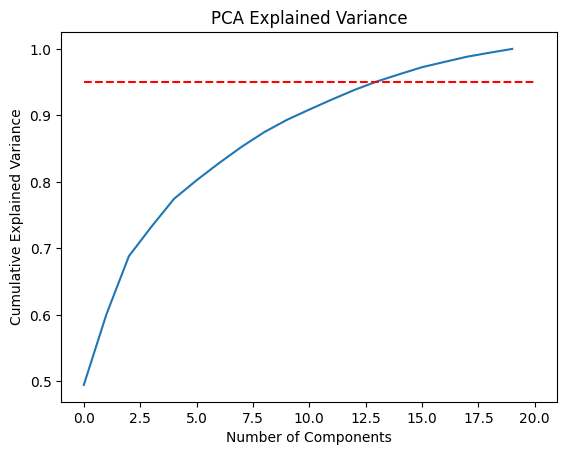

In [8]:
plt.plot(np.cumsum(pca_model.explained_variance_ratio_))
plt.hlines(cutoff, 0, len(cumulative_variance), colors='r', linestyles='dashed')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')

# Find best k

### Inertia

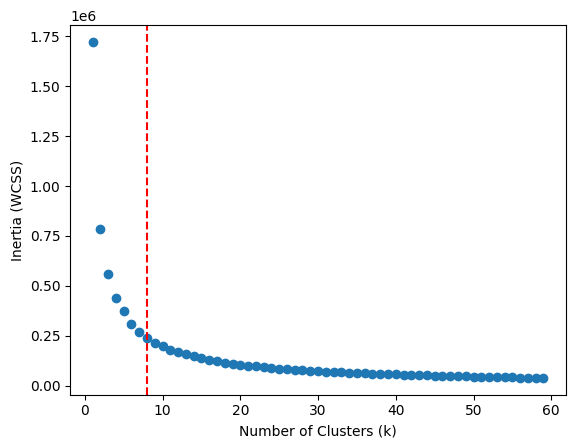

In [17]:

inertia_values = []
K = range(1, 60)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    cutoff = int(np.shape(X_super_pca)[0]*0.8)
    X_train = np.vstack([X_super_pca[:cutoff, 0], X_super_pca[:cutoff, 1]]).T
    kmeans.fit(X_train.copy())
    inertia_values.append(kmeans.inertia_)
    
kneedle = KneeLocator(K, inertia_values, curve="convex", direction="decreasing")
optimal_k = kneedle.knee
plt.axvline(x=optimal_k, color='r', linestyle='--', label=f'Elbow at k={optimal_k}')
# Plotting the inertia values
plt.scatter(K, inertia_values, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (WCSS)')
# plt.savefig(save_path+'inertia_values_session_part_clusters.svg', format="svg")

plt.show()

In [183]:
print(optimal_k)

4


# kMeans on supersession

In [9]:
# Loop through animals
sessions_to_process = []

for m, mat in enumerate(idxs):
    mouse_name = mat[37:]
    session = mat[:36]
    sessions_to_process.append((mouse_name, session))

print(len(sessions_to_process))

sessions_to_exclude = ['2d7c0f7f-e805-404b-914a-23d83998e08e', # bad right cam
'7691eeb3-715b-4571-8fda-6bb57aab8253', # bad view of paws
'bd8b204f-a42e-45c1-a8f0-71c6223a6657', # bad right camera
'f3eeb2d4-87ce-49ae-8a74-21665f6f1536', # moving licks
'650a0a90-4bf3-4489-9bcd-75baf0a49eac', # licks fail
'495bee7e-b58e-42ea-8481-4a1bfedca54a', # timestamps
'1db57661-5ad3-4465-b9ee-08473af9c2e8', # timestamps
'6a369bfa-a70b-4147-af25-d03772ff8d96', # timestamps
'7050ae29-a99e-43f1-aa42-b4416200351c', # timestamps
'3fa080ff-bcce-43e8-bd5f-601f0591f785', # timestamps
'5c454bcb-ae77-42da-a8d2-b6463ea9f21b', # bad licks
'c728f6fd-58e2-448d-aefb-a72c637b604c' # no data can be loaded
]

sessions_to_exclude = [
'30af8629-7b96-45b7-8778-374720ddbc5e',
'90e524a2-aa63-47ce-b5b8-1b1941a1223a',
'a8a8af78-16de-4841-ab07-fde4b5281a03',
'49368f16-de69-4647-9a7a-761e94517821',
'a71175be-d1fd-47a3-aa93-b830ea3634a1',
'0deb75fb-9088-42d9-b744-012fb8fc4afb',
'02fbb6da-3034-47d6-a61b-7d06c796a830',
'7f6b86f9-879a-4ea2-8531-294a221af5d0',
'8c33abef-3d3e-4d42-9f27-445e9def08f9',
'ebe2efe3-e8a1-451a-8947-76ef42427cc9',
'510b1a50-825d-44ce-86f6-9678f5396e02']


sessions_to_exclude = ['a8a8af78-16de-4841-ab07-fde4b5281a03',
    '8c33abef-3d3e-4d42-9f27-445e9def08f9',
    'ebe2efe3-e8a1-451a-8947-76ef42427cc9',
    # '0deb75fb-9088-42d9-b744-012fb8fc4afb',  # bad fit (should not be excluded here)
    # 'a71175be-d1fd-47a3-aa93-b830ea3634a1',  # bad fit (should not be excluded here)
    '91bac580-76ed-41ab-ac07-89051f8d7f6e',
    '8a1cf4ef-06e3-4c72-9bc7-e1baa189841b',
    # '02fbb6da-3034-47d6-a61b-7d06c796a830',  # bad fit (should not be excluded here)
    '64977c74-9c04-437a-9ea1-50386c4996db',
    '90e524a2-aa63-47ce-b5b8-1b1941a1223a',
    '30af8629-7b96-45b7-8778-374720ddbc5e',
    # '510b1a50-825d-44ce-86f6-9678f5396e02',  # bad fit (should not be excluded here)
    'f3eeb2d4-87ce-49ae-8a74-21665f6f1536',
    # '49368f16-de69-4647-9a7a-761e94517821',  # bad fit (should not be excluded here)
    # '7f6b86f9-879a-4ea2-8531-294a221af5d0',  # bad fit (should not be excluded here)
    'fcd49e34-f07b-441c-b2ac-cb8c462ec5ac']  # Ago 7 2026


sessions_to_process = [x for x in sessions_to_process if x not in sessions_to_exclude]


332


In [10]:
optimal_k = 10

kmeans = KMeans(n_clusters=optimal_k, random_state=2024)
kmeans.fit(X_super_pca.copy())
centroids = kmeans.cluster_centers_
cluster_values = kmeans.predict(X_super_pca)

## Propagate per session

In [11]:
global_mean = np.nanmean(X_super_mouse, axis=0)
global_std = np.nanstd(X_super_mouse, axis=0)

In [12]:
# assert len(sessions_to_process) == 319
for m, mat in enumerate(sessions_to_process):

    mouse_name = mat[0]
    session = mat[1]
    filename = wavelet_path + subname + str(session) + '_'  + mouse_name
    design_matrix = pd.read_parquet(filename)

    # z-score mouse data
    var_array = np.array(design_matrix[use_vars].copy())
    not_nan = ~np.isnan(var_array).any(axis=1)

    mouse_data = stats.zscore(var_array[not_nan, :], axis=0, nan_policy='omit') # z-score within session
    mouse_data = (mouse_data - global_mean) / global_std # z-score with global mean and std
    session_pca = pca_model.transform(mouse_data)[:, :optimal_n_components] # Transform using original PCA model trained on the supersession

    """ Compute clusters based on supersession centroids """
    # Compute distances between full dataset and trained centroids
    distances = cdist(session_pca, centroids, metric='euclidean')
    # Assign each point to the nearest centroid
    states = np.argmin(distances, axis=1)
    design_matrix[state_name] = np.nan
    design_matrix[state_name][not_nan] = states

    """ Save paw states with bins """
    # Save most_likely_states
    filename = states_path + "most_likely_states" + '_'+str(optimal_k)+'_'+ str(mouse_name+session)
    states_bin = np.array([states, np.array(design_matrix['Bin'][not_nan])])
    np.save(filename, states_bin)
    # Save most_likely_states
    filename = states_path + "centroid_distances" + '_'+str(optimal_k)+'_'+ str(mouse_name+session)
    np.save(filename, distances)

/tmp/ipykernel_149161/3942068270.py:23: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  design_matrix[state_name][not_nan] = states
/tmp/ipykernel_149161/3942068270.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a sli

OSError: Not enough free space to write 24233680 bytes

# Visualize cluster statistics

In [93]:
all_data = pd.DataFrame(X_super_mouse, columns=use_vars)
all_data[state_name] = cluster_values
wavelet_df = pd.melt(all_data, id_vars=[state_name], value_vars=use_vars)

# Wheel wavelets

In [94]:
palette = sns.color_palette('Set3', optimal_k, as_cmap=True)

In [95]:
fix_mapping = {0:1, 1:0, 2:2, 3:3}

replace_func = np.vectorize(fix_mapping.get)
wavelet_df['new_states'] = replace_func(wavelet_df['wheel_states'])

KeyError: 'wheel_states'

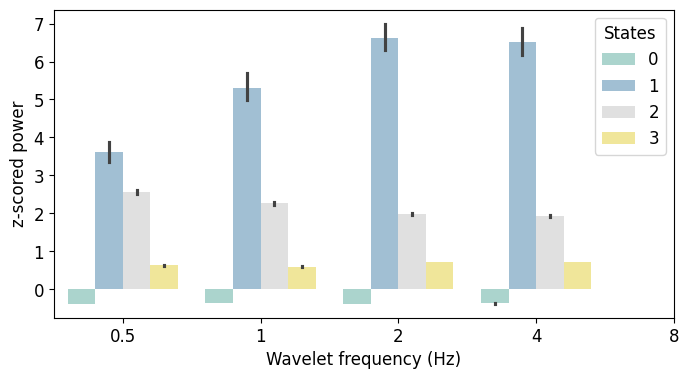

In [149]:
variables = ['avg_wheel_vel0.5', 'avg_wheel_vel1.0', 'avg_wheel_vel2.0', 'avg_wheel_vel4.0', 'avg_wheel_vel8.0',  'avg_wheel_vel16.0',  'avg_wheel_vel32.0']
variables = ['avg_wheel_vel2.0', 'avg_wheel_vel4.0', 'avg_wheel_vel8.0',  'avg_wheel_vel16.0',  'avg_wheel_vel32.0']


fig, ax = plt.subplots(figsize=[8, 4])
plt.rc('font', size=12)
use_states = 'wheel_states'
# use_states = 'new_states'
sns.barplot(hue=use_states, y='value', x='variable', ax=ax,
                data=wavelet_df.loc[wavelet_df['variable'].isin(variables)], palette=palette, alpha=.8)
plt.xticks([0, 1, 2, 3, 4], [0.5, 1, 2, 4, 8])
plt.xlabel('Wavelet frequency (Hz)')
plt.legend(title='States')
plt.ylabel('z-scored power')
plt.show()

/tmp/ipykernel_218008/3285926156.py:29: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  design_matrix[state_name][not_nan] = new_states
/tmp/ipykernel_218008/3285926156.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a

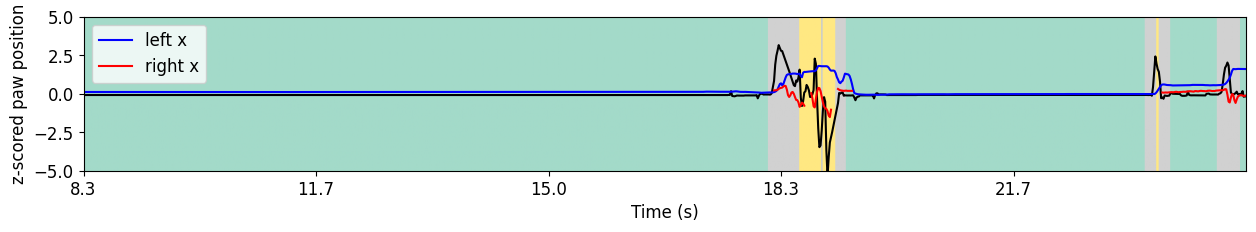

/tmp/ipykernel_218008/3285926156.py:29: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  design_matrix[state_name][not_nan] = new_states
/tmp/ipykernel_218008/3285926156.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a

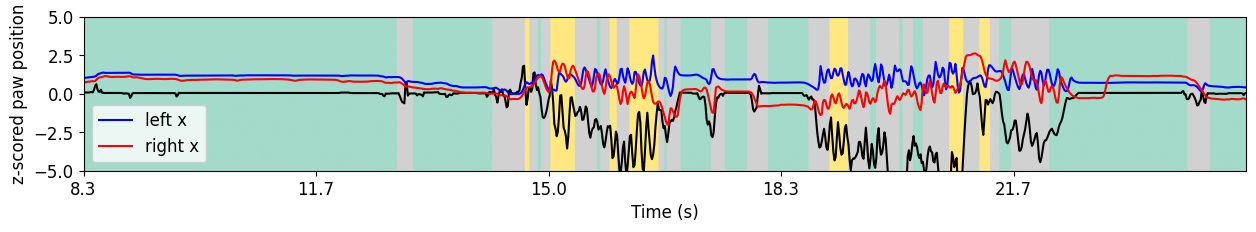

/tmp/ipykernel_218008/3285926156.py:29: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  design_matrix[state_name][not_nan] = new_states
/tmp/ipykernel_218008/3285926156.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a

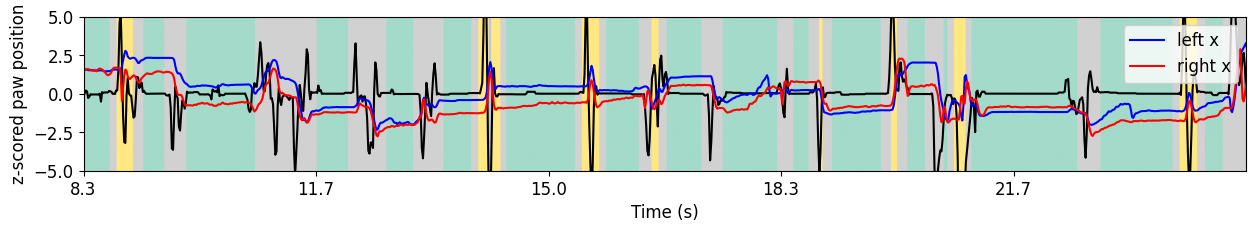

/tmp/ipykernel_218008/3285926156.py:29: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  design_matrix[state_name][not_nan] = new_states
/tmp/ipykernel_218008/3285926156.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a

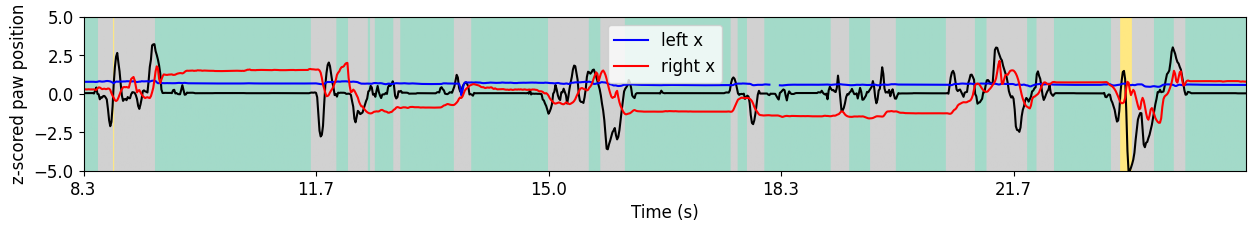

/tmp/ipykernel_218008/3285926156.py:29: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  design_matrix[state_name][not_nan] = new_states
/tmp/ipykernel_218008/3285926156.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a

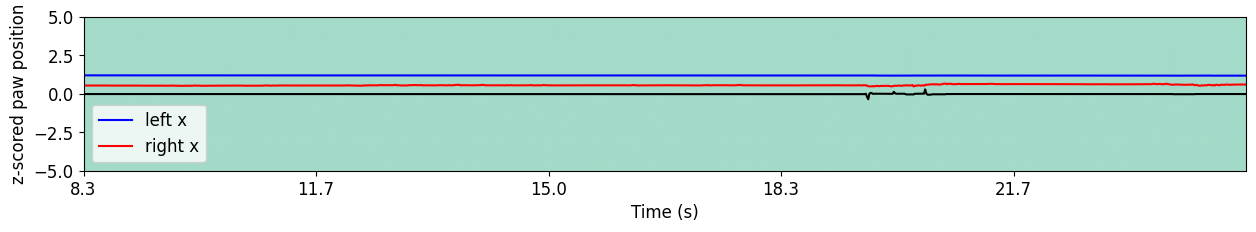

/tmp/ipykernel_218008/3285926156.py:29: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  design_matrix[state_name][not_nan] = new_states
/tmp/ipykernel_218008/3285926156.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a

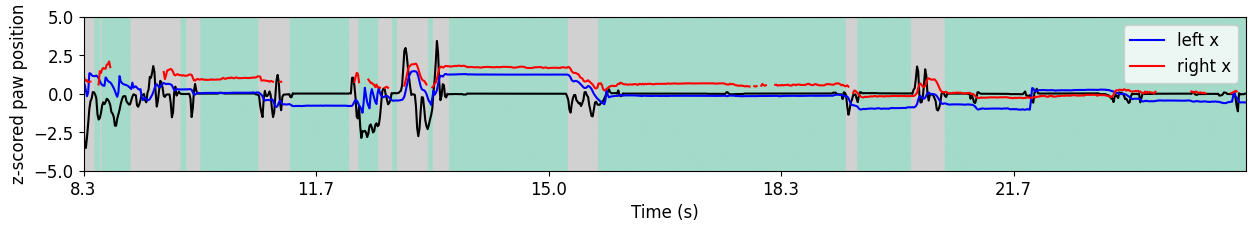

/tmp/ipykernel_218008/3285926156.py:29: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  design_matrix[state_name][not_nan] = new_states
/tmp/ipykernel_218008/3285926156.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a

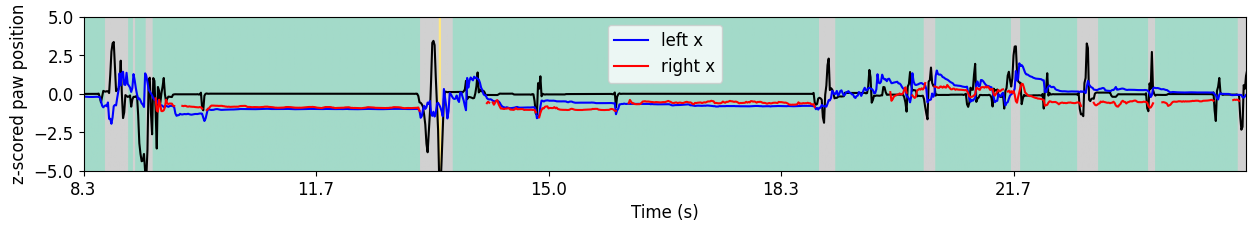

/tmp/ipykernel_218008/3285926156.py:29: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  design_matrix[state_name][not_nan] = new_states
/tmp/ipykernel_218008/3285926156.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a

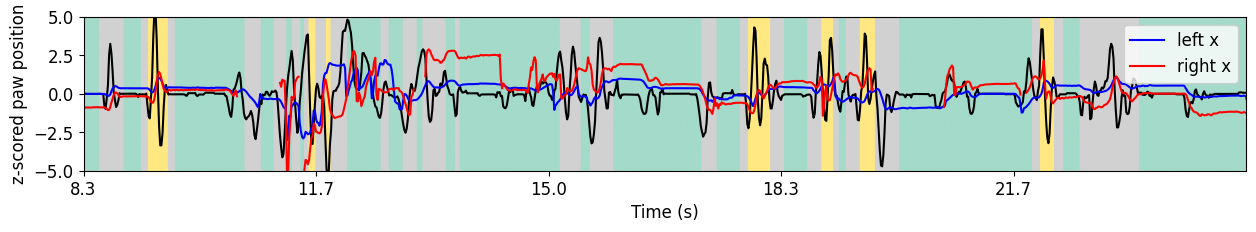

/tmp/ipykernel_218008/3285926156.py:29: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  design_matrix[state_name][not_nan] = new_states
/tmp/ipykernel_218008/3285926156.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a

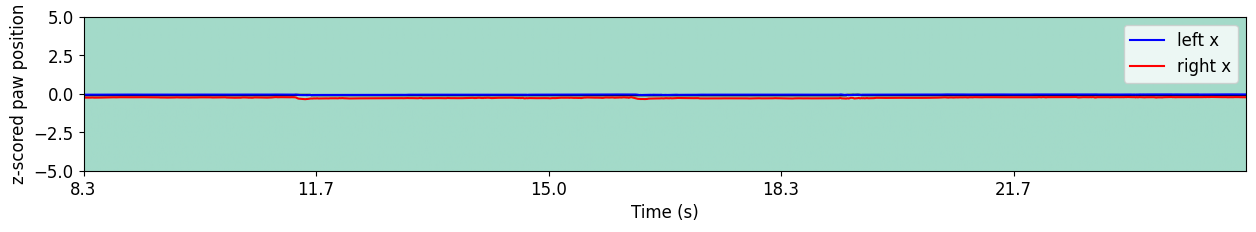

/tmp/ipykernel_218008/3285926156.py:29: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  design_matrix[state_name][not_nan] = new_states
/tmp/ipykernel_218008/3285926156.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a

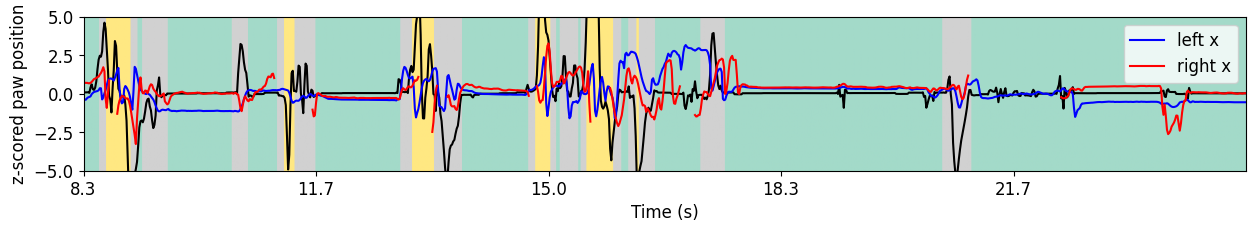

/tmp/ipykernel_218008/3285926156.py:29: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  design_matrix[state_name][not_nan] = new_states
/tmp/ipykernel_218008/3285926156.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a

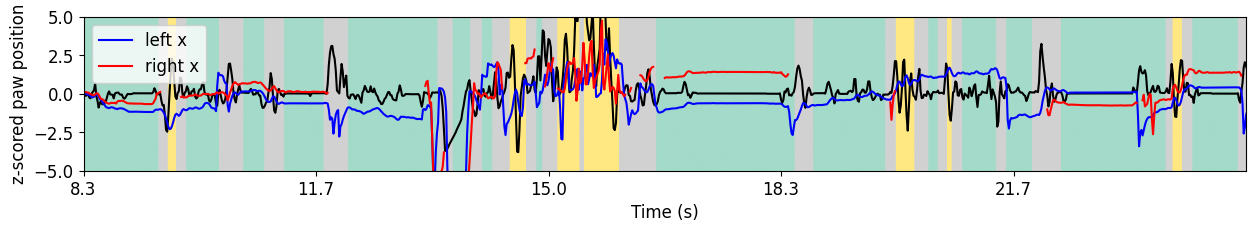

/tmp/ipykernel_218008/3285926156.py:29: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  design_matrix[state_name][not_nan] = new_states
/tmp/ipykernel_218008/3285926156.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a

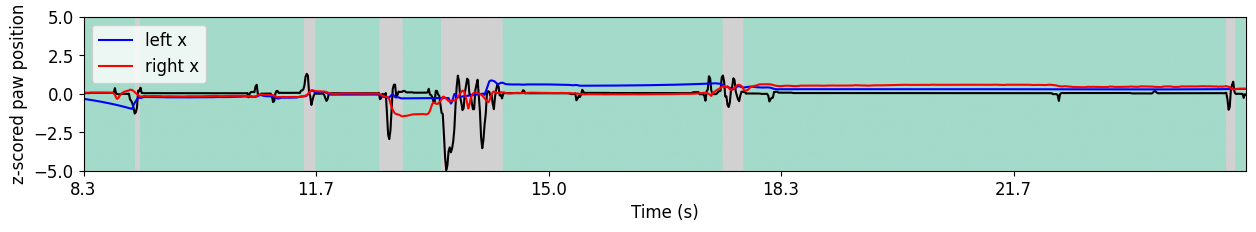

/tmp/ipykernel_218008/3285926156.py:29: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  design_matrix[state_name][not_nan] = new_states
/tmp/ipykernel_218008/3285926156.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a

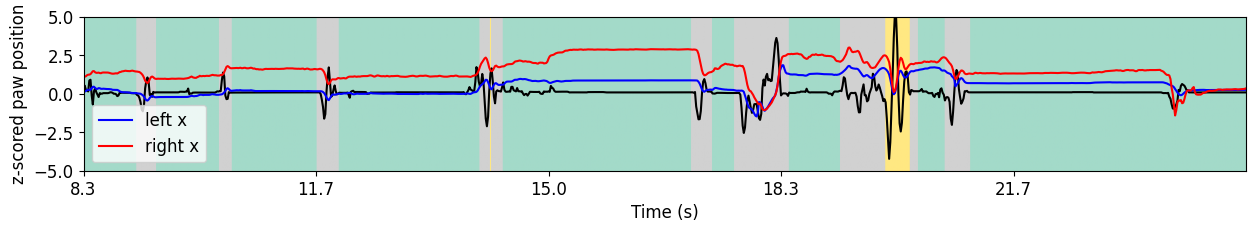

/tmp/ipykernel_218008/3285926156.py:29: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  design_matrix[state_name][not_nan] = new_states
/tmp/ipykernel_218008/3285926156.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a

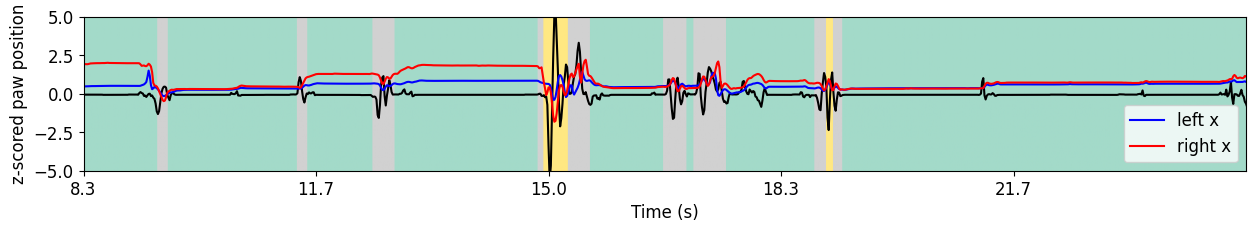

/tmp/ipykernel_218008/3285926156.py:29: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  design_matrix[state_name][not_nan] = new_states
/tmp/ipykernel_218008/3285926156.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a

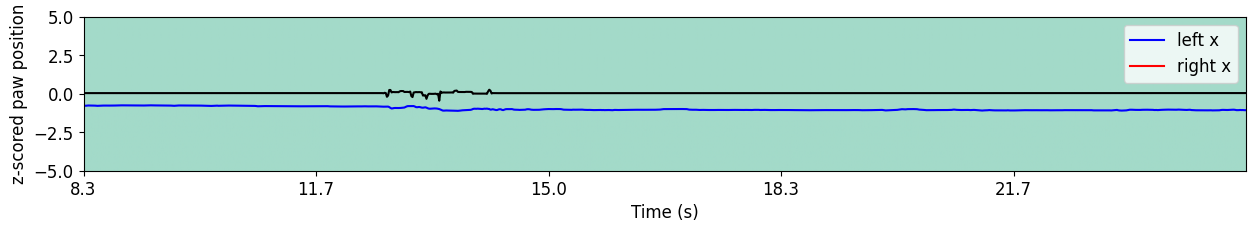

/tmp/ipykernel_218008/3285926156.py:29: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  design_matrix[state_name][not_nan] = new_states
/tmp/ipykernel_218008/3285926156.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a

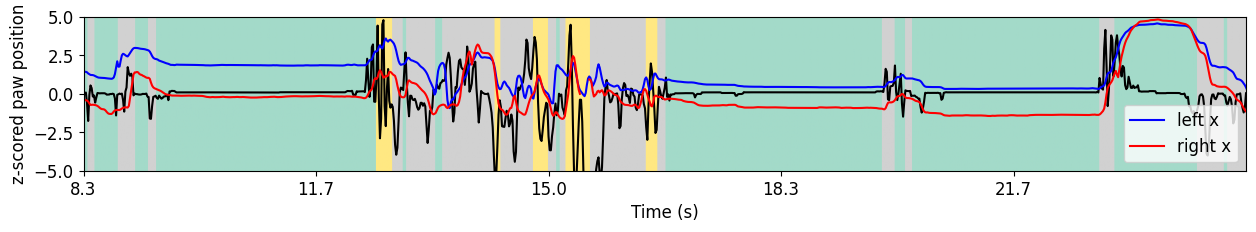

/tmp/ipykernel_218008/3285926156.py:29: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  design_matrix[state_name][not_nan] = new_states
/tmp/ipykernel_218008/3285926156.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a

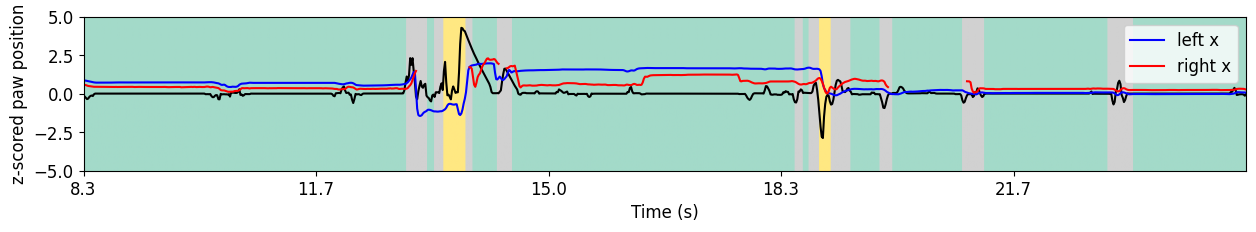

/tmp/ipykernel_218008/3285926156.py:29: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  design_matrix[state_name][not_nan] = new_states
/tmp/ipykernel_218008/3285926156.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a

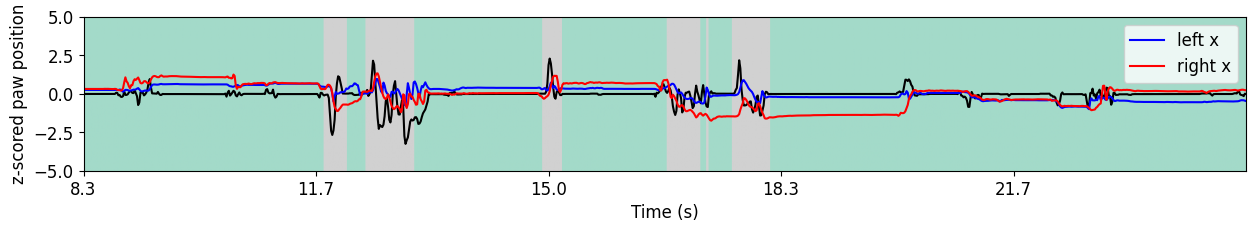

/tmp/ipykernel_218008/3285926156.py:29: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  design_matrix[state_name][not_nan] = new_states
/tmp/ipykernel_218008/3285926156.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a

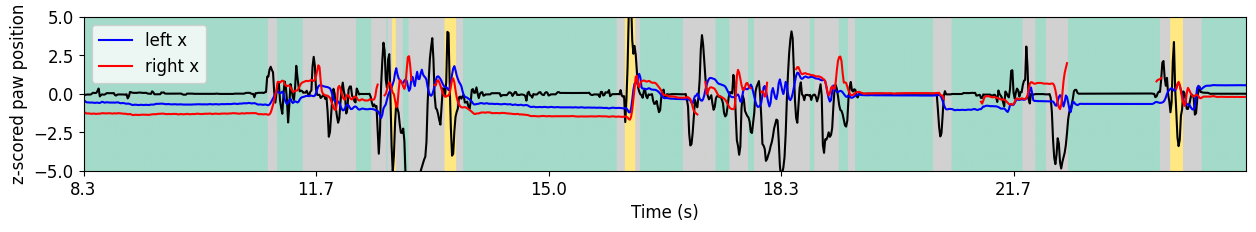

/tmp/ipykernel_218008/3285926156.py:29: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  design_matrix[state_name][not_nan] = new_states
/tmp/ipykernel_218008/3285926156.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a

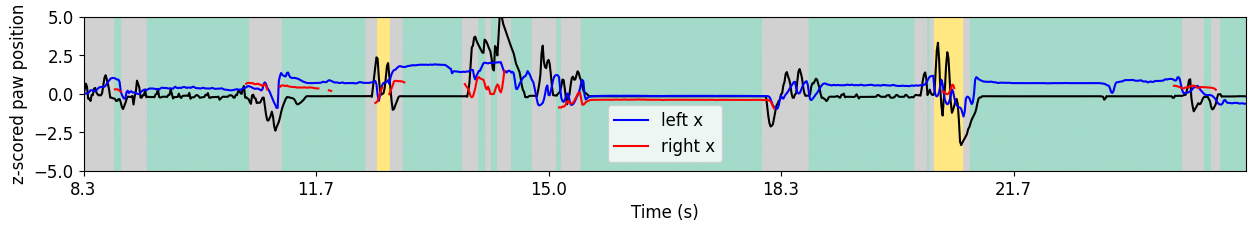

/tmp/ipykernel_218008/3285926156.py:29: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  design_matrix[state_name][not_nan] = new_states
/tmp/ipykernel_218008/3285926156.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a

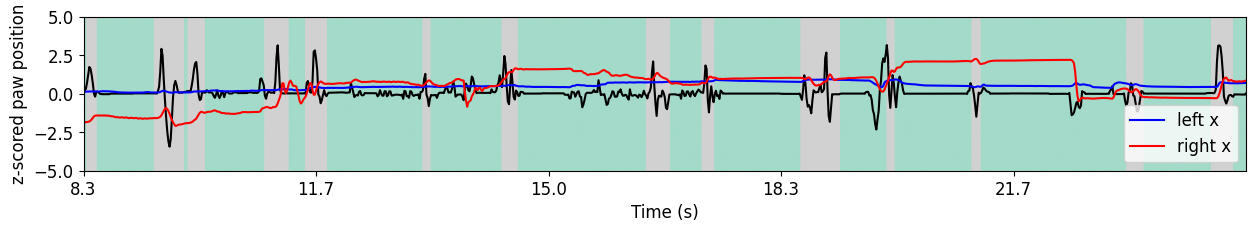

/tmp/ipykernel_218008/3285926156.py:29: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  design_matrix[state_name][not_nan] = new_states
/tmp/ipykernel_218008/3285926156.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a

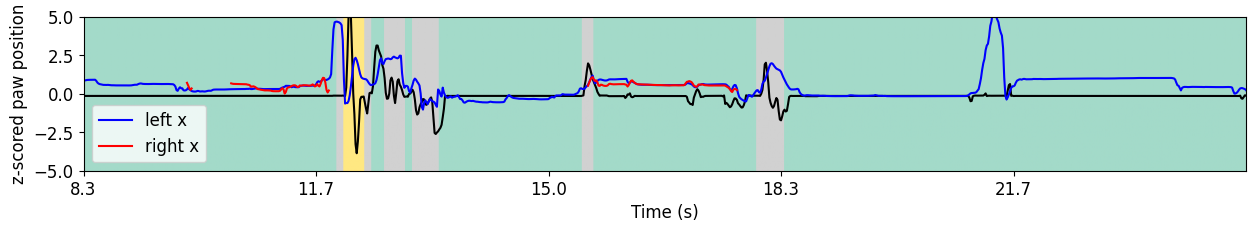

/tmp/ipykernel_218008/3285926156.py:29: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  design_matrix[state_name][not_nan] = new_states
/tmp/ipykernel_218008/3285926156.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a

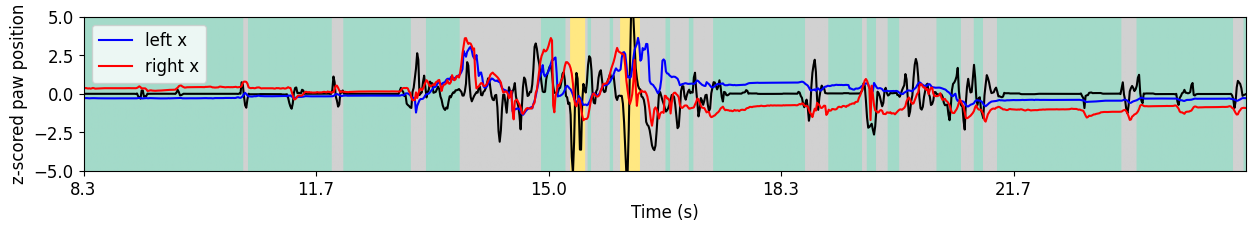

/tmp/ipykernel_218008/3285926156.py:29: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  design_matrix[state_name][not_nan] = new_states
/tmp/ipykernel_218008/3285926156.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a

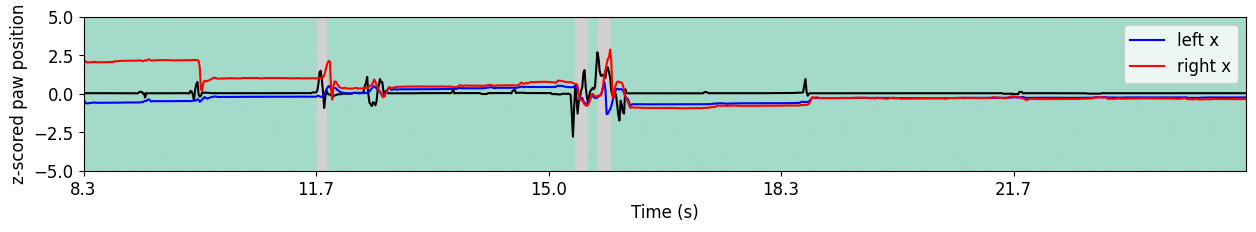

/tmp/ipykernel_218008/3285926156.py:29: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  design_matrix[state_name][not_nan] = new_states
/tmp/ipykernel_218008/3285926156.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a

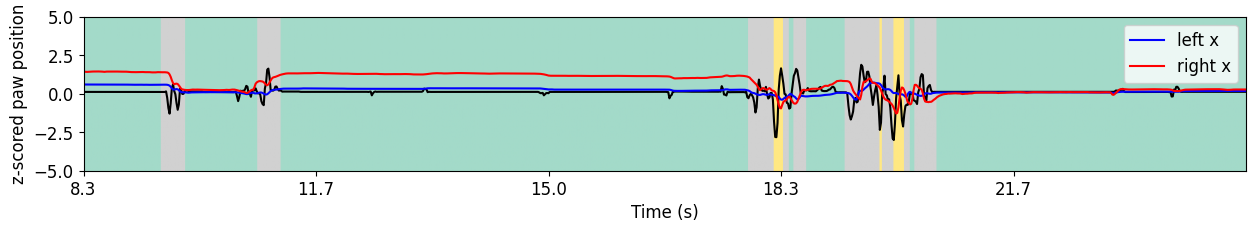

/tmp/ipykernel_218008/3285926156.py:29: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  design_matrix[state_name][not_nan] = new_states
/tmp/ipykernel_218008/3285926156.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a

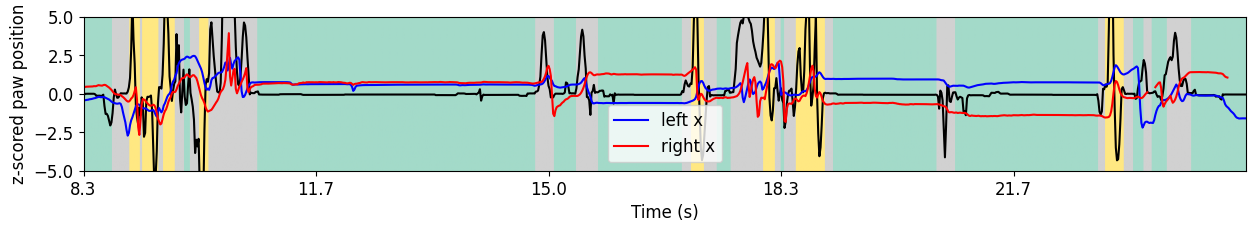

/tmp/ipykernel_218008/3285926156.py:29: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  design_matrix[state_name][not_nan] = new_states
/tmp/ipykernel_218008/3285926156.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a

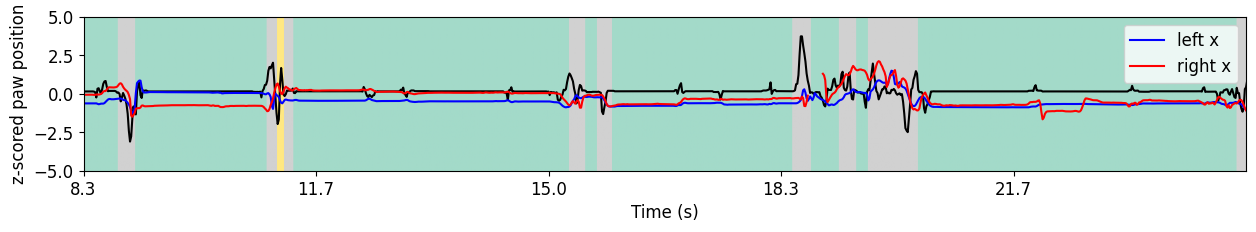

/tmp/ipykernel_218008/3285926156.py:29: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  design_matrix[state_name][not_nan] = new_states
/tmp/ipykernel_218008/3285926156.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a

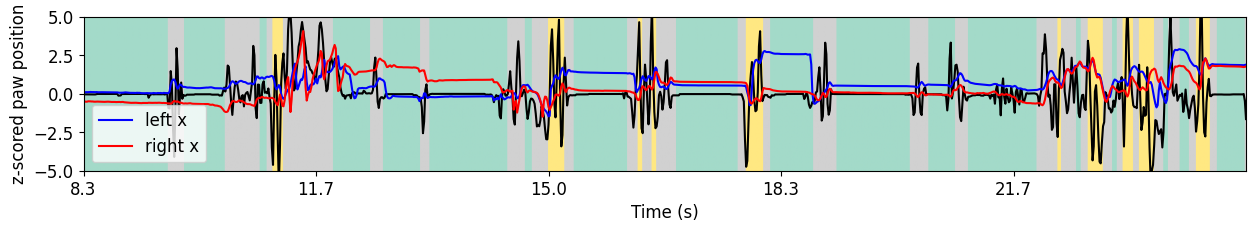

/tmp/ipykernel_218008/3285926156.py:29: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  design_matrix[state_name][not_nan] = new_states
/tmp/ipykernel_218008/3285926156.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a

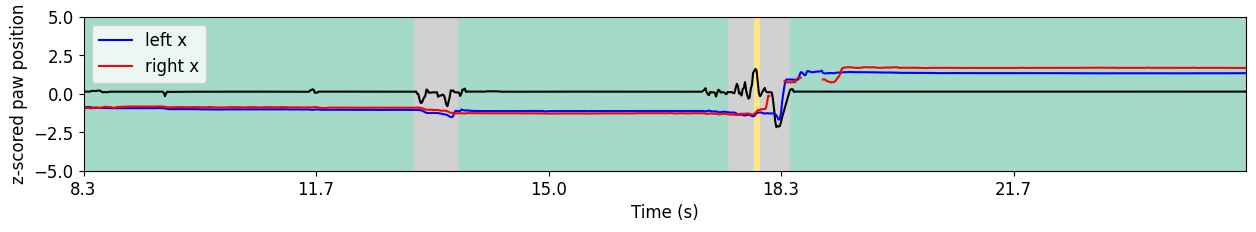

/tmp/ipykernel_218008/3285926156.py:29: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  design_matrix[state_name][not_nan] = new_states
/tmp/ipykernel_218008/3285926156.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a

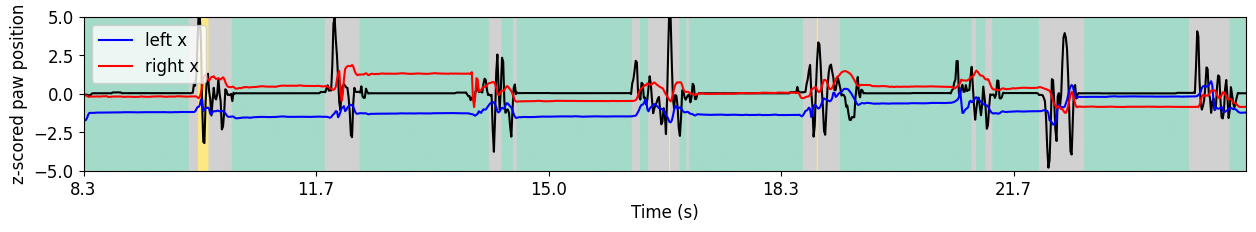

/tmp/ipykernel_218008/3285926156.py:29: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  design_matrix[state_name][not_nan] = new_states
/tmp/ipykernel_218008/3285926156.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a

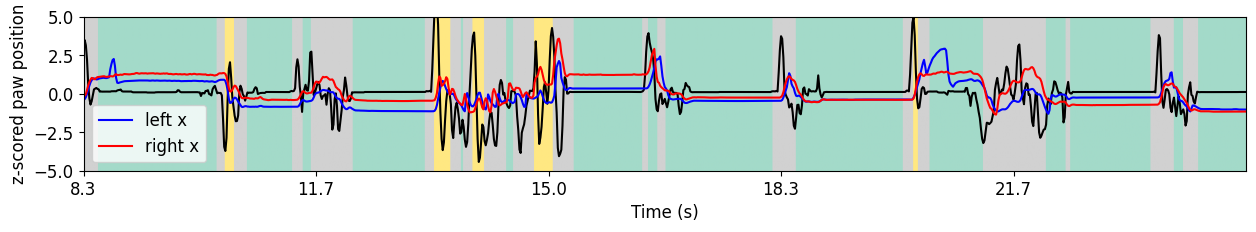

/tmp/ipykernel_218008/3285926156.py:29: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  design_matrix[state_name][not_nan] = new_states
/tmp/ipykernel_218008/3285926156.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a

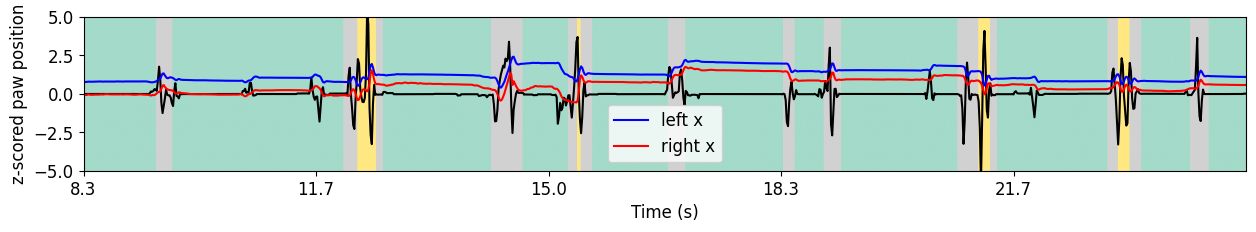

/tmp/ipykernel_218008/3285926156.py:29: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  design_matrix[state_name][not_nan] = new_states
/tmp/ipykernel_218008/3285926156.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a

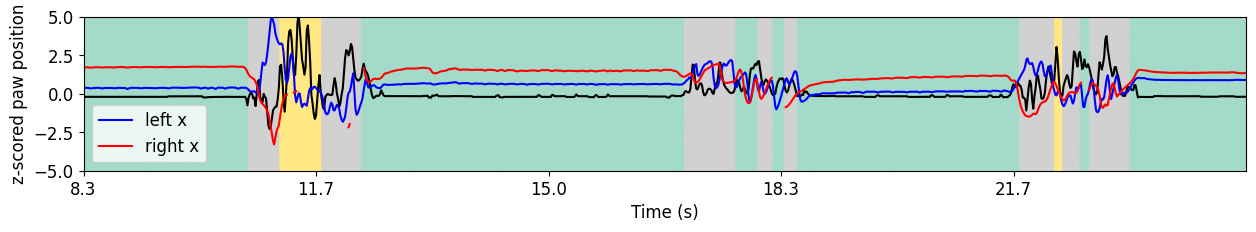

/tmp/ipykernel_218008/3285926156.py:29: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  design_matrix[state_name][not_nan] = new_states
/tmp/ipykernel_218008/3285926156.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a

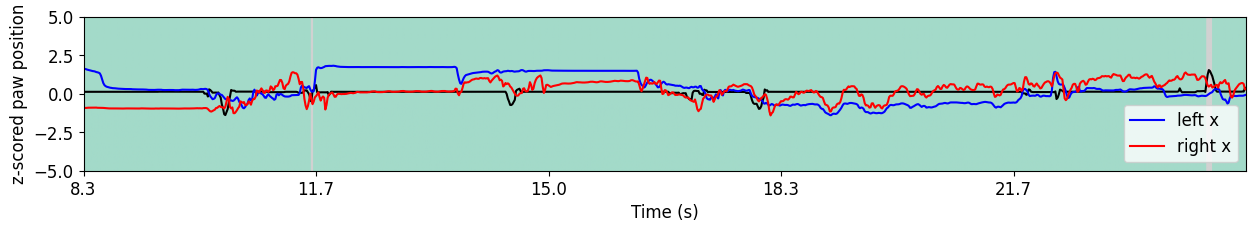

/tmp/ipykernel_218008/3285926156.py:29: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  design_matrix[state_name][not_nan] = new_states
/tmp/ipykernel_218008/3285926156.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a

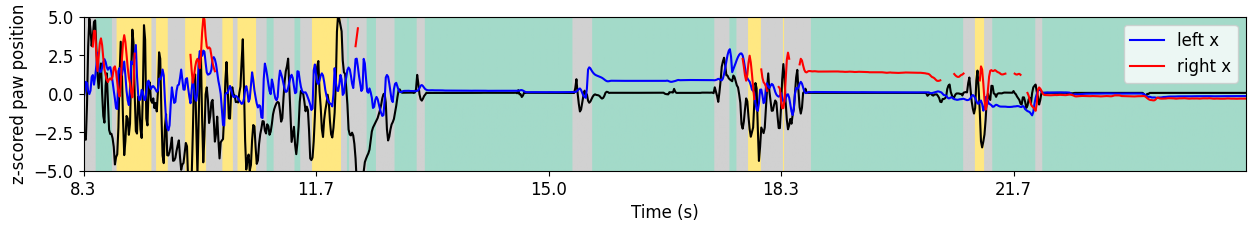

/tmp/ipykernel_218008/3285926156.py:29: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  design_matrix[state_name][not_nan] = new_states
/tmp/ipykernel_218008/3285926156.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a

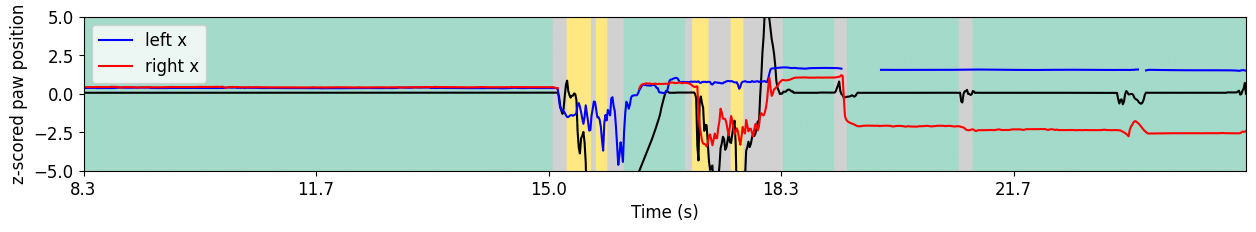

/tmp/ipykernel_218008/3285926156.py:29: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  design_matrix[state_name][not_nan] = new_states
/tmp/ipykernel_218008/3285926156.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a

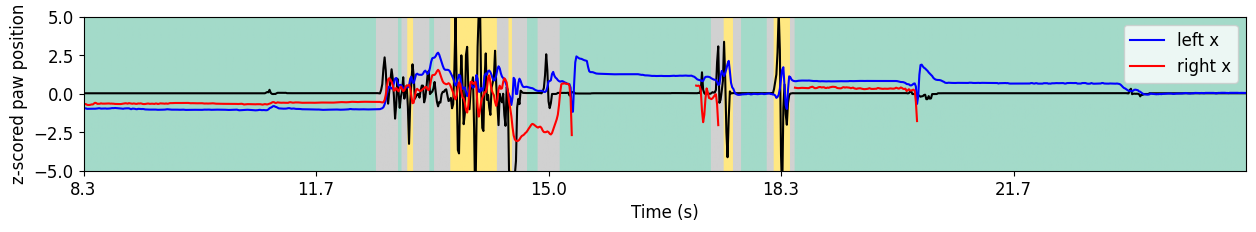

/tmp/ipykernel_218008/3285926156.py:29: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  design_matrix[state_name][not_nan] = new_states
/tmp/ipykernel_218008/3285926156.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a

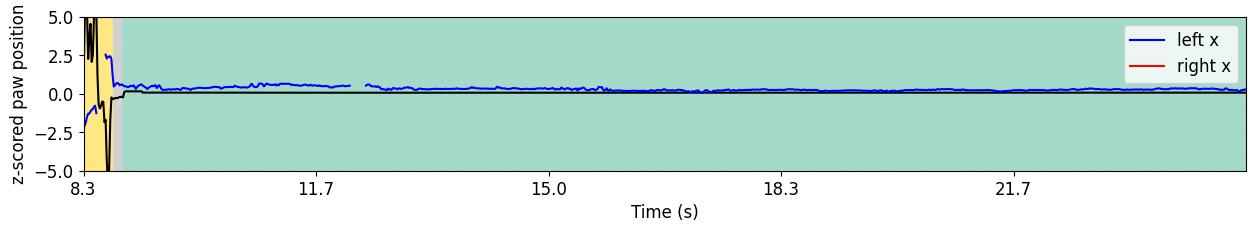

In [150]:
palette = sns.color_palette('Set2', n_colors=optimal_k, as_cmap=True)

# assert len(sessions_to_process) == 218
for m, mat in enumerate(sessions_to_process):

    mouse_name = mat[0]
    session = mat[1]
        
    filename = wavelet_path + subname + str(session) + '_'  + mouse_name
    design_matrix = pd.read_parquet(filename)

    # Prepare data
    # data_df = design_matrix[var_interest].copy().dropna()
    # data = np.array(data_df)

    var_array = np.array(design_matrix[use_vars].copy())
    not_nan = ~np.isnan(var_array).any(axis=1)
    mouse_data = stats.zscore(var_array[not_nan, :], axis=0, nan_policy='omit')
        
    """ Compute clusters based on supersession centroids """
    # Compute distances between full dataset and trained centroids
    distances = cdist(mouse_data, centroids, metric='euclidean')
    # Assign each point to the nearest centroid
    states = np.argmin(distances, axis=1)
    # replace_func = np.vectorize(paw_mapping.get)
    # new_states = replace_func(states)
    new_states = states
    design_matrix[state_name] = np.nan
    design_matrix[state_name][not_nan] = new_states
    
    # fig, ax = plt.subplots(ncols=1 , nrows=1, sharex=False, sharey=False, figsize=[20, 5])
    # plt.rc('font', size=12)
    # init = 000
    # ax.plot(stats.zscore(design_matrix.loc[design_matrix['Bin']>=init, 'avg_wheel_vel'].reset_index()['avg_wheel_vel'], nan_policy='omit'), color='black', label='wheel')
    # ax.plot(stats.zscore(design_matrix.loc[design_matrix['Bin']>=init, 'l_paw_x'].reset_index()['l_paw_x'], nan_policy='omit'), alpha=.5, color='green', label='left x')
    # ax.plot(stats.zscore(design_matrix.loc[design_matrix['Bin']>=init, 'l_paw_y'].reset_index()['l_paw_y'], nan_policy='omit'), alpha=.5, linestyle='--', color='green', label='left y')
    # ax.plot(stats.zscore(design_matrix.loc[design_matrix['Bin']>=init, 'r_paw_x'].reset_index()['r_paw_x'], nan_policy='omit'), alpha=.5, color='red', label='right x')
    # ax.plot(stats.zscore(design_matrix.loc[design_matrix['Bin']>=init, 'r_paw_y'].reset_index()['r_paw_y'], nan_policy='omit'), alpha=.5, linestyle='--',color='red', label='right y')
    # attach_array = np.arange(0, optimal_k, 1)
    # ax.imshow(np.concatenate([design_matrix.loc[design_matrix['Bin']>=init, state_name]])[None,:],
    #             extent=(0, len(np.concatenate([design_matrix.loc[design_matrix['Bin']>=init, state_name]])), -10, 10),
    #             aspect="auto",
    #             alpha=0.6,
    #             cmap=palette)  # 
    # init=2000
    # plt.xlim([init, init+1000])
    # plt.ylim([-8, 8])
    # plt.legend()
    # plt.show()
    # # plt.hist(states)
    # # plt.show()
    

    
    fig, ax = plt.subplots(ncols=1 , nrows=1, sharex=False, sharey=False, figsize=[15, 2])
    plt.rc('font', size=12)
    init = 1000
    ax.plot(stats.zscore(design_matrix.loc[design_matrix['Bin']>=init, 'avg_wheel_vel'].reset_index()['avg_wheel_vel'], nan_policy='omit'), color='black')
    ax.plot(stats.zscore(design_matrix.loc[design_matrix['Bin']>=init, 'l_paw_x'].reset_index()['l_paw_x'], nan_policy='omit'), color='blue', label='left x')
    # ax.plot(stats.zscore(design_matrix.loc[design_matrix['Bin']>=init, 'l_paw_y'].reset_index()['l_paw_y'], nan_policy='omit'), linestyle='--', color='green', label='left y')
    ax.plot(stats.zscore(design_matrix.loc[design_matrix['Bin']>=init, 'r_paw_x'].reset_index()['r_paw_x'], nan_policy='omit'), color='red', label='right x')
    # ax.plot(stats.zscore(design_matrix.loc[design_matrix['Bin']>=init, 'r_paw_y'].reset_index()['r_paw_y'], nan_policy='omit'), linestyle='--',color='red', label='right y')
    attach_array = np.arange(0, optimal_k, 1)
    ax.imshow(np.concatenate([design_matrix.loc[design_matrix['Bin']>=init, state_name].reset_index()[state_name]])[None,:],
                extent=(0, len(np.concatenate([design_matrix.loc[design_matrix['Bin']>=init, state_name].reset_index()[state_name]])), -10, 10),
                aspect="auto",
                alpha=0.6,
                cmap=palette)  
    init=500
    plt.xlim([init, init+1000])
    plt.ylabel('z-scored paw position')
    plt.xlabel('Time (s)')
    plt.ylim([-5, 5])
    inter = 1000
    frame_rate = 60
    plt.xticks(np.arange(init, init+inter, inter/5), np.round(np.arange(init/frame_rate, 
                  (init+inter)/frame_rate, (inter/frame_rate)/5), 1))
    plt.legend()
    plt.show()

# Paw wavelets

In [96]:
use_states = 'left_paw_states'
use_states = 'paw_states'

In [100]:
if optimal_k == 8:
        fix_mapping = {0: 4,
        1:0,
        2:3,
        3:1,
        4:6,
        5:7,
        6:2,
        7:5
        }  # for z-scored t-SNE
        paw_fix_mapping = {0:4, 1:1, 2:5, 3:7, 4:6, 5:2, 6:0, 7:3}

        fix_mapping = {0: 3,
        1:1,
        2:2,
        3:6,
        4:7,
        5:0,
        6:4,
        7:5
        }  # 1Apr2026

        fix_mapping = {0: 3,
        1:0,
        2:7,
        3:4,
        4:5,
        5:2,
        6:6,
        7:1
        }  # 12June2026
        fix_mapping = {0: 0,
        1:2,
        2:1,
        3:6,
        4:7,
        5:5,
        6:4,
        7:3
        }  # 19 Ago2026

elif optimal_k == 10:

        fix_mapping = {0: 3,
        1:1,
        2:7,
        3:4,
        4:5,
        5:6,
        6:8,
        7:2, 
        8:9, 
        9:0
        }  # 12June2026
elif optimal_k == 6:
        fix_mapping = {0: 2,
        1:0,
        2:4,
        3:5,
        4:3,
        5:1
        }  
        fix_mapping = {0: 0,
        1:5,
        2:4,
        3:1,
        4:2,
        5:3
        }  # 19Ago2026
elif optimal_k == 7:
        fix_mapping = {0: 3,
        1:0,
        2:5,
        3:6,
        4:4,
        5:2,
        6:1
        } 
elif optimal_k == 9:
        fix_mapping = {0: 3,
        1:0,
        2:6,
        3:4,
        4:5,
        5:2,
        6:7,
        7:1, 
        8:8, 
        }  # 12June2026
elif optimal_k == 4:
    fix_mapping = {0: 0, 1: 1, 2: 2, 3: 3}
replace_func = np.vectorize(fix_mapping.get)
wavelet_df['Paw syllables'] = replace_func(wavelet_df[use_states])

In [101]:
palette=sns.color_palette('Set3', optimal_k)

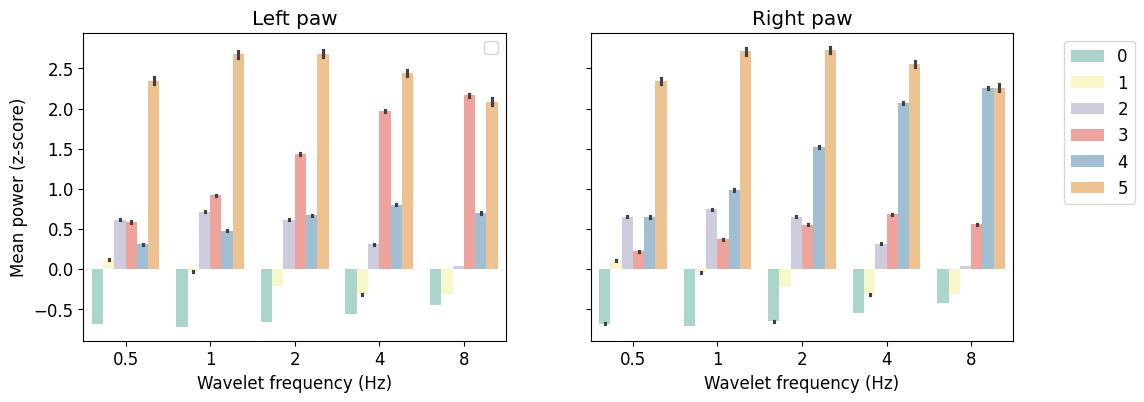

In [102]:
x_left = ['l_paw_x0.5', 'l_paw_x1.0', 'l_paw_x2.0', 'l_paw_x4.0', 'l_paw_x8.0']
x_right = ['r_paw_x0.5', 'r_paw_x1.0', 'r_paw_x2.0', 'r_paw_x4.0', 'r_paw_x8.0']

fig, ax = plt.subplots(ncols=2 , nrows=1, sharex=False, sharey=True, figsize=[12, 4])
plt.rc('font', size=12)
use_states = 'Paw syllables'
# use_states = 'paw_states'
sns.barplot(hue=use_states, y='value', x='variable', ax=ax[0],
                data=wavelet_df.loc[wavelet_df['variable'].isin(x_left)], palette=palette, alpha=.8)
ax[0].set_title('Left paw')
sns.barplot(hue=use_states, y='value', x='variable', ax=ax[1],
                data=wavelet_df.loc[wavelet_df['variable'].isin(x_right)], palette=palette, alpha=.8)
ax[0].set_xlabel('Wavelet frequency (Hz)')
ax[1].set_xlabel('Wavelet frequency (Hz)')
ax[1].set_title('Right paw')
ax[0].set_ylabel('Mean power (z-score)')
ax[0].set_xticks([0, 1, 2, 3, 4], [0.5, 1, 2, 4, 8])
ax[1].set_xticks([0, 1, 2, 3, 4], [0.5, 1, 2, 4, 8])
ax[0].legend('')
ax[1].legend(loc='upper left', bbox_to_anchor=(1.1, 1))
# fig.savefig(prefix + 'representation_learning_variability/paper-individuality/figures/'+'wavelet_states.svg', format='svg', bbox_inches='tight')

plt.show()

## Left paw only

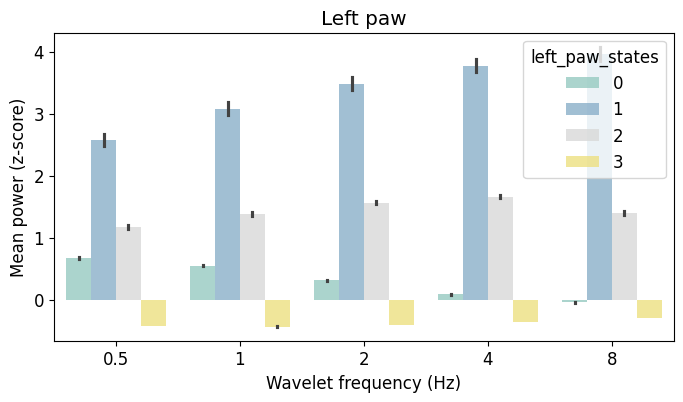

In [73]:
x_left = ['l_paw_x0.5', 'l_paw_x1.0', 'l_paw_x2.0', 'l_paw_x4.0', 'l_paw_x8.0']

fig, ax = plt.subplots(ncols=1 , nrows=1, sharex=False, sharey=True, figsize=[8, 4])
plt.rc('font', size=12)
use_states = 'Paw syllables'
use_states = 'left_paw_states'
sns.barplot(hue=use_states, y='value', x='variable', 
                data=wavelet_df.loc[wavelet_df['variable'].isin(x_left)], palette=palette, alpha=.8)
plt.title('Left paw')
plt.xlabel('Wavelet frequency (Hz)')
plt.ylabel('Mean power (z-score)')
plt.xticks([0, 1, 2, 3, 4], [0.5, 1, 2, 4, 8])
# fig.savefig(prefix + 'representation_learning_variability/paper-individuality/figures/'+'wavelet_states.svg', format='svg', bbox_inches='tight')

plt.show()

## Visualize example session

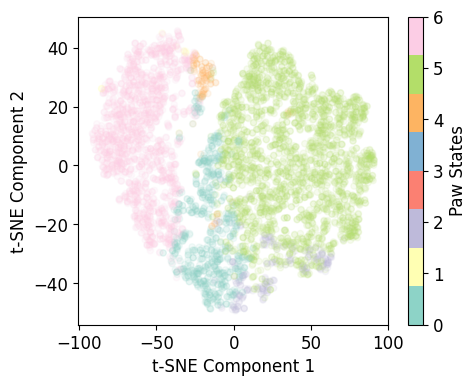

In [20]:
for m, mat in enumerate(sessions_to_process[:1]):

    mouse_name = mat[0]
    session = mat[1]
    filename = wavelet_path + subname + str(session) + '_'  + mouse_name
    design_matrix = pd.read_parquet(filename)

    var_array = np.array(design_matrix[use_vars].copy())
    not_nan = ~np.isnan(var_array).any(axis=1)
    mouse_data = stats.zscore(var_array[not_nan, :], axis=0, nan_policy='omit')
    mouse_data = (var_array[not_nan, :] - global_mean)/global_std
    session_pca = pca_model.transform(mouse_data)[:, :optimal_n_components] # Transform using original PCA model trained on the supersession

    """ Compute clusters based on supersession centroids """
    # Compute distances between full dataset and trained centroids
    distances = cdist(session_pca, centroids, metric='euclidean')
    # Assign each point to the nearest centroid
    states = np.argmin(distances, axis=1)
    replace_func = np.vectorize(fix_mapping.get)
    new_states = replace_func(states)
    
    # Downsample the data before t-SNE to improve performance
    n_samples = min(5000, session_pca.shape[0])  # Use max 5000 samples or all available
    if session_pca.shape[0] > n_samples:
        total_frames = session_pca.shape[0]
        indices = np.random.choice(total_frames, size=n_samples, replace=False)
        mouse_data_downsampled = session_pca[indices]
    else:
        mouse_data_downsampled = session_pca

    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    mouse_data_2d = tsne.fit_transform(mouse_data_downsampled)

    plt.figure(figsize=(5, 4))
    paw_cmap = ListedColormap(sns.color_palette('Set3', n_colors=8))
    scatter = plt.scatter(mouse_data_2d[:, 0], mouse_data_2d[:, 1], 
                        c=new_states[indices], cmap=paw_cmap, s=20, alpha=0.1)
    cbar = plt.colorbar(scatter, label='Paw States')
    cbar.solids.set_alpha(1)
    plt.xlabel('t-SNE Component 1')
    plt.ylabel('t-SNE Component 2')
    # plt.savefig(prefix + 'representation_learning_variability/paper-individuality/figures/'+'wavelet_tsne.png', 
    #             format='png', bbox_inches='tight', dpi=150)
    plt.show()

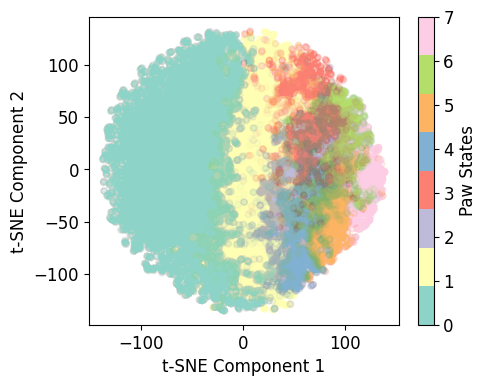

In [ ]:
plt.figure(figsize=(5, 4))
paw_cmap = ListedColormap(sns.color_palette('Set3', n_colors=8))
scatter = plt.scatter(mouse_data_2d[:, 0], mouse_data_2d[:, 1], 
                     c=new_states, cmap=paw_cmap, s=20, alpha=0.01)
cbar = plt.colorbar(scatter, label='Paw States')
cbar.solids.set_alpha(1)
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
# plt.savefig(prefix + 'representation_learning_variability/paper-individuality/figures/'+'wavelet_tsne.png', 
#             format='png', bbox_inches='tight', dpi=150)
plt.show()


/tmp/ipykernel_112730/2430337153.py:40: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  design_matrix[use_states][not_nan] = new_states
/tmp/ipykernel_112730/2430337153.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a

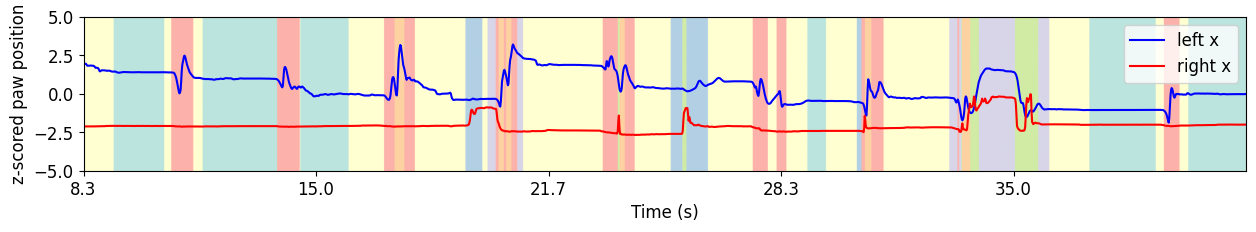

/tmp/ipykernel_112730/2430337153.py:40: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  design_matrix[use_states][not_nan] = new_states
/tmp/ipykernel_112730/2430337153.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a

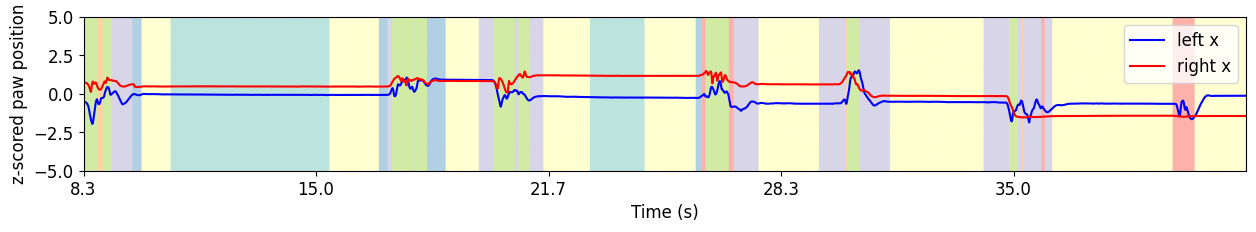

/tmp/ipykernel_112730/2430337153.py:40: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  design_matrix[use_states][not_nan] = new_states
/tmp/ipykernel_112730/2430337153.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a

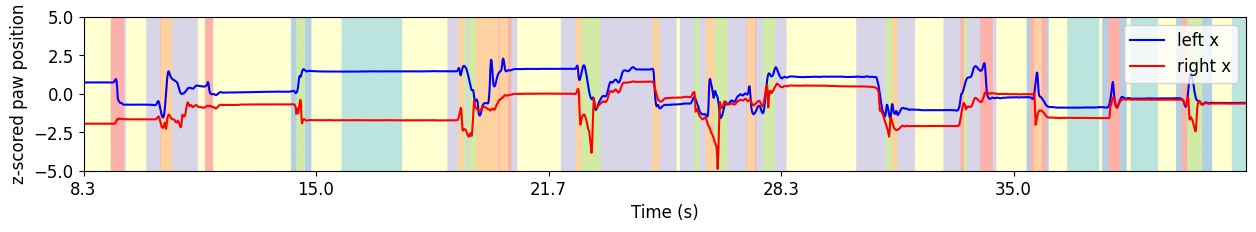

/tmp/ipykernel_112730/2430337153.py:40: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  design_matrix[use_states][not_nan] = new_states
/tmp/ipykernel_112730/2430337153.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a

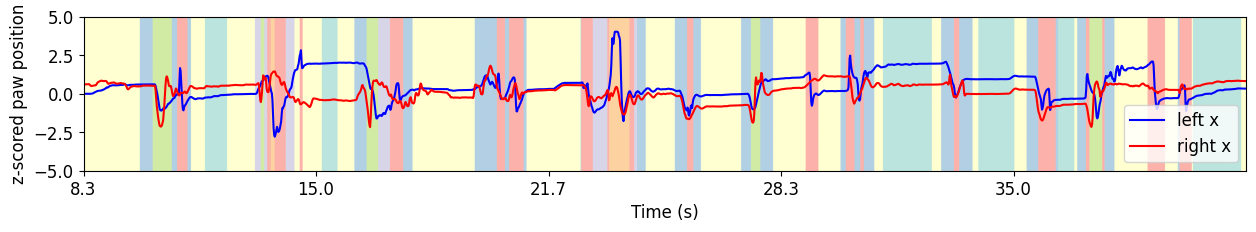

/tmp/ipykernel_112730/2430337153.py:40: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  design_matrix[use_states][not_nan] = new_states
/tmp/ipykernel_112730/2430337153.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a

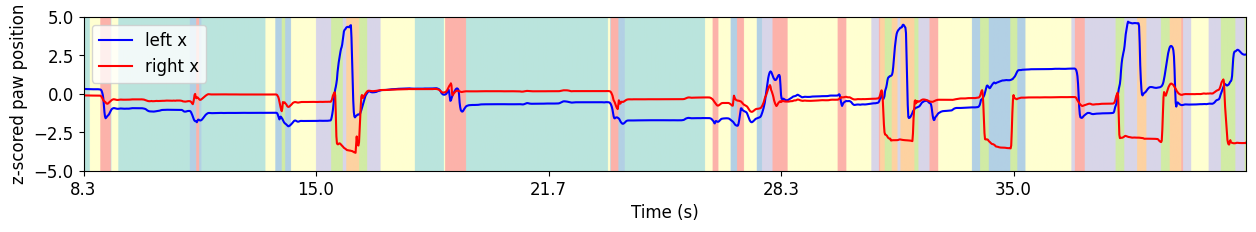

/tmp/ipykernel_112730/2430337153.py:40: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  design_matrix[use_states][not_nan] = new_states
/tmp/ipykernel_112730/2430337153.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a

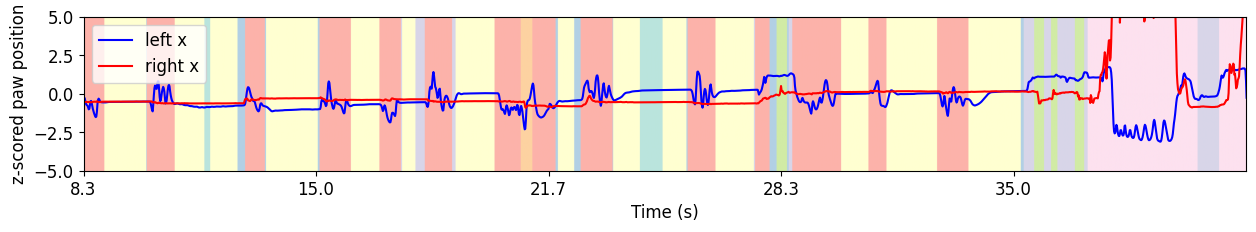

/tmp/ipykernel_112730/2430337153.py:40: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  design_matrix[use_states][not_nan] = new_states
/tmp/ipykernel_112730/2430337153.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a

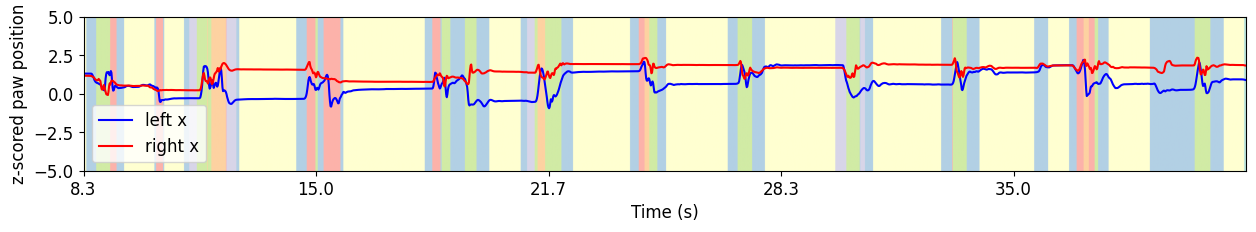

/tmp/ipykernel_112730/2430337153.py:40: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  design_matrix[use_states][not_nan] = new_states
/tmp/ipykernel_112730/2430337153.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a

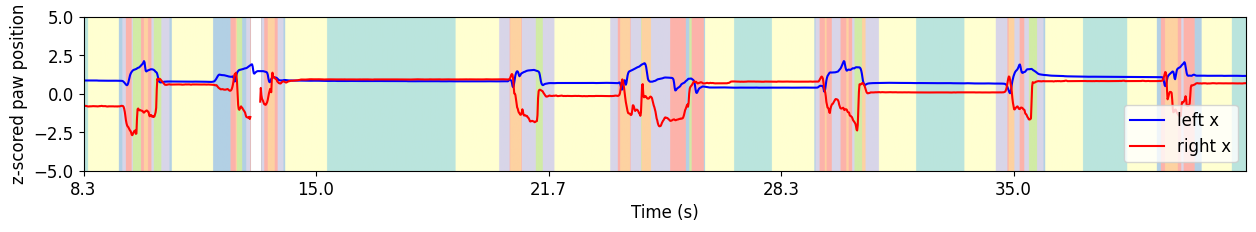

/tmp/ipykernel_112730/2430337153.py:40: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  design_matrix[use_states][not_nan] = new_states
/tmp/ipykernel_112730/2430337153.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a

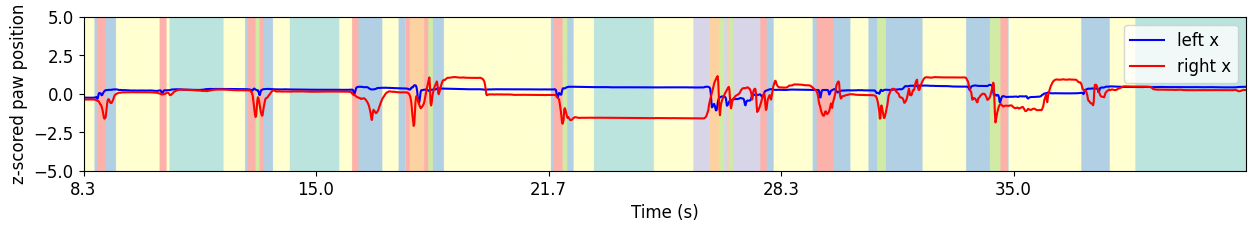

/tmp/ipykernel_112730/2430337153.py:40: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  design_matrix[use_states][not_nan] = new_states
/tmp/ipykernel_112730/2430337153.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a

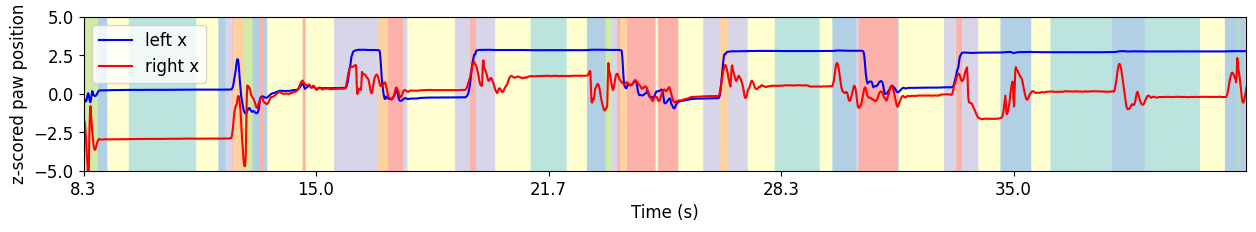

In [81]:

palette = sns.color_palette('Set3', n_colors=optimal_k, as_cmap=True)
paw_cmap = ListedColormap(sns.color_palette('Set3', n_colors=8))

# assert len(sessions_to_process) == 218
for m, mat in enumerate(sessions_to_process[:10]):

    mouse_name = mat[0]
    session = mat[1]
    filename = wavelet_path + subname + str(session) + '_'  + mouse_name
    design_matrix = pd.read_parquet(filename)
    
    # Base the NaN mask on a chosen subset — r_paw_* have many gaps, so don't drop rows for them
    nan_vars = use_vars if var != 'left_paw' else [v for v in use_vars if v not in ('r_paw_x', 'r_paw_y')]

    # Prepare data: keep all use_vars as features, but drop rows only on nan_vars
    var_array = design_matrix[use_vars].to_numpy(dtype=float)
    not_nan   = ~design_matrix[nan_vars].isna().to_numpy().any(axis=1)

    mouse_data = stats.zscore(var_array[not_nan, :], axis=0, nan_policy='omit')
    mouse_data = (mouse_data - global_mean) / global_std
    mouse_data = np.nan_to_num(mouse_data, nan=0.0)   # mean-impute leftover r_paw gaps (0 == mean in standardized space)
    session_pca = pca_model.transform(mouse_data)[:, :optimal_n_components]

    # # Prepare data
    # var_array = np.array(design_matrix[use_vars].copy())
    # not_nan = ~np.isnan(var_array).any(axis=1)
    # mouse_data = stats.zscore(var_array[not_nan, :], axis=0, nan_policy='omit')
    # mouse_data = (mouse_data - global_mean)/global_std
    # session_pca = pca_model.transform(mouse_data)[:, :optimal_n_components] # Transform using original PCA model trained on the supersession
        
    """ Compute clusters based on supersession centroids """
    # Compute distances between full dataset and trained centroids
    distances = cdist(session_pca, centroids, metric='euclidean')
    # Assign each point to the nearest centroid
    states = np.argmin(distances, axis=1)
    replace_func = np.vectorize(fix_mapping.get)
    new_states = replace_func(states)
    # new_states = states
    design_matrix[use_states] = np.nan
    design_matrix[use_states][not_nan] = new_states
    
    fig, ax = plt.subplots(ncols=1 , nrows=1, sharex=False, sharey=False, figsize=[15, 2])
    plt.rc('font', size=12)
    init = 1000
    # ax.plot(design_matrix.loc[design_matrix['Bin']>=init, 'avg_wheel_vel'].reset_index(), color='black')
    ax.plot(stats.zscore(design_matrix.loc[design_matrix['Bin']>=init, 'l_paw_x'].reset_index()['l_paw_x'], nan_policy='omit'), color='blue', label='left x')
    # ax.plot(stats.zscore(design_matrix.loc[design_matrix['Bin']>=init, 'l_paw_y'].reset_index()['l_paw_y'], nan_policy='omit'), linestyle='--', color='green', label='left y')
    ax.plot(stats.zscore(design_matrix.loc[design_matrix['Bin']>=init, 'r_paw_x'].reset_index()['r_paw_x'], nan_policy='omit'), color='red', label='right x')
    # ax.plot(stats.zscore(design_matrix.loc[design_matrix['Bin']>=init, 'r_paw_y'].reset_index()['r_paw_y'], nan_policy='omit'), linestyle='--',color='red', label='right y')
    attach_array = np.arange(0, optimal_k, 1)
    ax.imshow(np.concatenate([design_matrix.loc[design_matrix['Bin']>=init, use_states].reset_index()[use_states]])[None,:],
                extent=(0, len(np.concatenate([design_matrix.loc[design_matrix['Bin']>=init, use_states].reset_index()[use_states]])), -10, 10),
                aspect="auto",
                alpha=0.6,
                cmap=paw_cmap)  
    init=500
    plt.xlim([init, init+2000])
    plt.ylabel('z-scored paw position')
    plt.xlabel('Time (s)')
    plt.ylim([-5, 5])
    inter = 2000
    frame_rate = 60
    plt.xticks(np.arange(init, init+inter, inter/5), np.round(np.arange(init/frame_rate, 
                  (init+inter)/frame_rate, (inter/frame_rate)/5), 1))
    plt.legend()
    plt.show()

    # # Downsample the data before t-SNE to improve performance
    # n_samples = min(5000, session_pca.shape[0])  # Use max 5000 samples or all available
    # if session_pca.shape[0] > n_samples:
    #     total_frames = session_pca.shape[0]
    #     indices = np.random.choice(total_frames, size=n_samples, replace=False)
    #     mouse_data_downsampled = session_pca[indices]
    # else:
    #     mouse_data_downsampled = session_pca

    # tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    # mouse_data_2d = tsne.fit_transform(mouse_data_downsampled)

    # plt.figure(figsize=(5, 4))
    # paw_cmap = ListedColormap(sns.color_palette('Set3', n_colors=8))
    # scatter = plt.scatter(mouse_data_2d[:, 0], mouse_data_2d[:, 1], 
    #                     c=new_states[indices], cmap=paw_cmap, s=20, alpha=0.5)
    # cbar = plt.colorbar(scatter, label='Paw States')
    # cbar.solids.set_alpha(1)
    # plt.xlabel('t-SNE Component 1')
    # plt.ylabel('t-SNE Component 2')
    # # plt.savefig(prefix + 'representation_learning_variability/paper-individuality/figures/'+'wavelet_tsne.png', 
    # #             format='png', bbox_inches='tight', dpi=150)
    # plt.show()
    